1) Importing libs

In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_tavily import TavilySearch
from dotenv import load_dotenv
import os
from typing import TypedDict, Literal
from IPython.display import Image, display

/home/ash/pygame_310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2 Loading env 

In [2]:
load_dotenv()
groq_api_key = os.getenv("GROQ_API_KEY")
tavily_api_key = os.getenv("TAVILY_API_KEY")


2.2 Creating the llm

In [3]:
llm = ChatGroq(
    model="llama-3.3",
    api_key=groq_api_key
)

2.3 Search tool

In [4]:
search_tool = TavilySearch(
    max_result = 3,
    tavily_api_key=tavily_api_key
)

ValidationError: 1 validation error for TavilySearchAPIWrapper
  Value error, Did not find tavily_api_key, please add an environment variable `TAVILY_API_KEY` which contains it, or pass `tavily_api_key` as a named parameter. [type=value_error, input_value={'tavily_api_key': ''}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/value_error

3. Defining the state

In [5]:
class AgentState(TypedDict):
    question: str
    route: Literal["research", "direct"]
    search_results:str
    answer:str

4. Creating the Planner node

In [6]:
def planner_node(state: AgentState):
    prompt = f"""
    You are an intelligent research planner.

    Decide whether the following question requires web research.

    Question:
    {state["question"]}

    If web research is required, respond with only:
    research

    Otherwise respond with only:
    direct
    """

    response = llm.invoke(prompt)

    route = response.content.strip().lower()

    if route not in ["research", "direct"]:
        route = "research"

    return {
        "route": route
    }

5. Creating the Research node

In [7]:
def research_node(state: AgentState):
    results = search_tool.invoke(state["question"])
    return {
        "search_results": results
    }

6. Creating the writer node

In [8]:
def writer_node(state: AgentState):
    prompt = f"""
    Answer the following question using the provided search results.

    Question:
    {state["question"]}

    Search Results:
    {state["search_results"]}

    Provide a clear and well-structured answer.
    """

    response = llm.invoke(prompt)

    return {
        "answer": response.content
    }

7. Creating the Graph

In [9]:
graph = StateGraph(AgentState)

graph.add_node("planner", planner_node)
graph.add_node("research",research_node)
graph.add_node("writer", writer_node)

8.Connecting the nodes

In [10]:
graph.add_edge(START, "planner")

graph.add_conditional_edges(
    "planner",
    lambda state: state["route"],
    {
        "research":"research",
        "direct":"writer"
    }
)
graph.add_edge("research","writer")
graph.add_edge("writer", END)

9. Compiling the Graph

In [11]:
app = graph.compile()

10. Visualizing the Graph

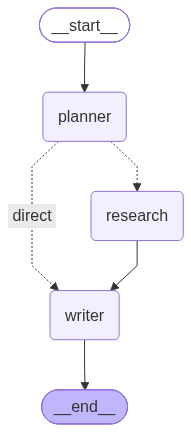

In [17]:
display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

11. Running the Graph

In [19]:
question = input("Enter your question: ")

result = app.invoke(
    {
        "question": question
    }
)

print("\nAnswer:\n")
print(result["answer"])

APIConnectionError: Connection error.